### Questão 5

**Enunciado:** Um sistema de segurança bancária classificou 15 transações como "Suspeitas" (1) ou "Seguras" (0). Você deve avaliar se este modelo é confiável o suficiente para ser colocado em produção, considerando que o banco prefere bloquear uma transação legítima por engano do que deixar passar uma fraude real. Construa a Matriz de Confusão no seu notebook. Calcule a Acurácia, a Precisão e a Revocação. Com base na preferência do banco (mencionada no problema), qual dessas métricas é a mais importante neste cenário? Justifique sua resposta analisando o impacto dos Falsos Negativos.

**Problema:** Avaliar a confiabilidade de um modelo de detecção de fraudes bancárias, onde prioriza-se bloquear transações legítimas por engano a deixar passar uma fraude real.

**Conceito Apropriado:** ``Matriz de Confusão`` e ``Métrica de Revocação (Recall)``.

**Justificativa:** Para avaliar o desempenho de modelos de classificação e visualizar exatamente onde o modelo está acertando e errando, utilizamos a Matriz de Confusão. Neste contexto de negócio, o Falso Negativo é o mais perigoso. Portanto, a métrica de Revocação torna-se essencial, pois ela indica a proporção de positivos reais (fraudes) que foram identificados corretamente.

#### **Importando as bibliotecas**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Previsões do Modelo: [1 0 1 1 0 1 0 0 1 1 0 1 0 0 1]
Valores Reais: [1 0 0 1 1 1 0 0 1 0 0 1 1 0 1]


#### **Carregamento do Dataset**

In [12]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows=1
    dados = np.loadtxt('datasets/dataset_q5.csv', delimiter=',', skiprows=1, usecols=(1, 2))

    y_pred = dados[:, 1]
    y_true = dados[:, 0]

    # Visualiza os dados
    # 1 = Fraude/Suspeita (Positivo), 0 = Segura/Legítima (Negativo)
    print("y_pred:", y_pred)
    print("y_true:", y_true)

    print("\n Número de amostras:", y_pred.shape[0])

except FileNotFoundError:
    print("Erro: Arquivo do dataset não encontrado.")
    exit()

y_pred: [1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1.]
y_true: [1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1.]

 Número de amostras: 15


#### **Cálculo dos componentes da Matriz de Confusão**

In [ ]:
# Verdadeiro Positivo: O modelo previu Positivo (1) e o real era Positivo (1)
VP = np.sum((y_true == 1) & (y_pred == 1))

# Verdadeiro Negativo: O modelo previu Negativo (0) e o real era Negativo (0)
VN = np.sum((y_true == 0) & (y_pred == 0))

# Falso Positivo: O modelo previu Positivo (1), mas o real era Negativo (0)
FP = np.sum((y_true == 0) & (y_pred == 1))

# Falso Negativo: O modelo previu Negativo (0), mas o real era Positivo (1)
FN = np.sum((y_true == 1) & (y_pred == 0))

print("=== Matriz de Confusão ===")
print(f"Verdadeiros Positivos (VP): {VP}")
print(f"Verdadeiros Negativos (VN): {VN}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")

=== Matriz de Confusão ===
Verdadeiros Positivos (VP): 6
Verdadeiros Negativos (VN): 5
Falsos Positivos (FP): 2
Falsos Negativos (FN): 2


#### **Cálculo das Métricas de Avaliação**

In [ ]:
# Acurácia: proporção geral de previsões corretas
acuracia = (VP + VN) / (VP + VN + FP + FN) #

# Precisão: proporção de previsões positivas que estavam corretas
precisao = VP / (VP + FP) if (VP + FP) > 0 else 0 #

# Revocação: proporção de positivos reais identificados corretamente
revocacao = VP / (VP + FN) if (VP + FN) > 0 else 0 #

print("=== Métricas de Desempenho ===")
print(f"Acurácia: {acuracia:.4f} ({(acuracia*100):.1f}%)")
print(f"Precisão: {precisao:.4f} ({(precisao*100):.1f}%)")
print(f"Revocação: {revocacao:.4f} ({(revocacao*100):.1f}%)")

=== Métricas de Desempenho ===
Acurácia: 0.7333 (73.3%)
Precisão: 0.7500 (75.0%)
Revocação: 0.7500 (75.0%)


#### **Visualização da Matriz de Confusão em Gráfico**

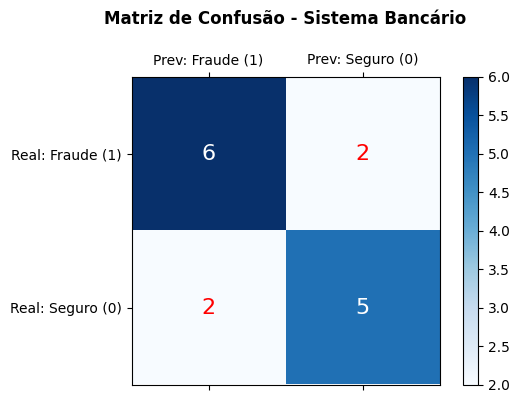

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
matriz = np.array([[VP, FN], [FP, VN]])
cax = ax.matshow(matriz, cmap='Blues')
plt.colorbar(cax)

for (i, j), val in np.ndenumerate(matriz):
    ax.text(j, i, f'{val}', ha='center', va='center', fontsize=16, 
            color='red' if val < max(VP, VN, FP, FN)/2 else 'white')

plt.xticks([0, 1], ['Prev: Fraude (1)', 'Prev: Seguro (0)'])
plt.yticks([0, 1], ['Real: Fraude (1)', 'Real: Seguro (0)'])
plt.title('Matriz de Confusão - Sistema Bancário\n', fontweight='bold')
plt.show()

#### **Interpretação dos Resultados para o Negócio**

Neste cenário bancário, o **Falso Negativo (FN)** (o modelo classificar uma fraude real como sendo uma transação segura) representa o erro mais perigoso e custoso para a instituição. 

Portanto, a métrica crítica que deve ser rigorosamente monitorada é a **Revocação (Recall)**, uma vez que ela é essencial quando o custo de um Falso Negativo é muito alto. A Precisão não é a melhor escolha aqui, pois foca na proporção de previsões positivas corretas e penaliza os Falsos Positivos (bloqueios indevidos), o que vai de encontro à política do banco de preferir um alarme falso a deixar um problema real não detectado.